In [2]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# heatmaps calmap
import calmap
import logging
# hide font warnings
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
# file paths
flights_path = 'all_flights_2018-2022.parquet'
weather_path = 'weather_airports_2018_2022_CLEAN.parquet'
merged_path = 'flight_weather_merged.parquet'

print('Flights:', flights_path)
print('Weather:', weather_path)
print('Merged :', merged_path)

# quick scale check
flights_pf = pq.ParquetFile(flights_path)
weather_pf = pq.ParquetFile(weather_path)
fw_merged_pf = pq.ParquetFile(merged_path)


print('\nFlights rows:', flights_pf.metadata.num_rows)
print('Weather rows:', weather_pf.metadata.num_rows)
print('Merged rows :', fw_merged_pf.metadata.num_rows)

Flights: all_flights_2018-2022.parquet
Weather: weather_airports_2018_2022_CLEAN.parquet
Merged : flight_weather_merged.parquet

Flights rows: 29193782
Weather rows: 15620936
Merged rows : 24165691


In [4]:
# find missingness percentage
def parquet_missingness(parquet_file, cols=None, batch_size=300_000):
    if cols is None:
        cols = parquet_file.schema.names
    miss = pd.Series(0, index=cols, dtype='int64')
    total=0

    for i, batch in enumerate(parquet_file.iter_batches(batch_size=batch_size, columns=cols), start=1):
        b = batch.to_pandas()
        total += len(b)
        miss += b.isna().sum().astype('int64')
    out = (miss / max(total, 1) * 100).sort_values(ascending=False)
    return out, total 
            

In [5]:
# flight columns
all_flight_cols = flights_pf.schema.names
print('Total columns:', len(all_flight_cols))
print('Total rows   :', flights_pf.metadata.num_rows)
print('\nColumns:\n', all_flight_cols)


Total columns: 62
Total rows   : 29193782

Columns:
 ['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted', 'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSA

In [6]:
flights_df = pd.read_parquet('all_flights_2018-2022.parquet')
display(flights_df.head(5))

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,year
0,2018-01-23,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1256.0,0.0,38.0,62.0,59.0,145.0,2018,1,1,23,2,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8928A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,14.0,1211.0,1249.0,7.0,1304,-8.0,0.0,-1.0,1300-1359,1,0.0,2018
1,2018-01-24,Endeavor Air Inc.,ABY,ATL,False,False,1202,1157.0,0.0,-5.0,1258.0,0.0,36.0,62.0,61.0,145.0,2018,1,1,24,3,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,13.0,1210.0,1246.0,12.0,1304,-6.0,0.0,-1.0,1300-1359,1,0.0,2018
2,2018-01-25,Endeavor Air Inc.,ABY,ATL,False,False,1202,1153.0,0.0,-9.0,1302.0,0.0,40.0,62.0,69.0,145.0,2018,1,1,25,4,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8836A,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,18.0,1211.0,1251.0,11.0,1304,-2.0,0.0,-1.0,1300-1359,1,0.0,2018
3,2018-01-26,Endeavor Air Inc.,ABY,ATL,False,False,1202,1150.0,0.0,-12.0,1253.0,0.0,35.0,62.0,63.0,145.0,2018,1,1,26,5,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N800AY,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1200-1259,17.0,1207.0,1242.0,11.0,1304,-11.0,0.0,-1.0,1300-1359,1,0.0,2018
4,2018-01-27,Endeavor Air Inc.,ABY,ATL,False,False,1400,1355.0,0.0,-5.0,1459.0,0.0,36.0,60.0,64.0,145.0,2018,1,1,27,6,DL,DL_CODESHARE,19790,DL,3298,9E,20363,9E,N8839E,3298,10146,1014602,30146,"Albany, GA",GA,13,Georgia,34,10397,1039707,30397,"Atlanta, GA",GA,13,Georgia,34,0.0,-1.0,1400-1459,17.0,1412.0,1448.0,11.0,1500,-1.0,0.0,-1.0,1500-1559,1,0.0,2018


In [8]:
# datatypes
display(flights_df.dtypes)

FlightDate                                 datetime64[us]
Airline                                            object
Origin                                             object
Dest                                               object
Cancelled                                            bool
Diverted                                             bool
CRSDepTime                                          int64
DepTime                                           float64
DepDelayMinutes                                   float64
DepDelay                                          float64
ArrTime                                           float64
ArrDelayMinutes                                   float64
AirTime                                           float64
CRSElapsedTime                                    float64
ActualElapsedTime                                 float64
Distance                                          float64
Year                                                int64
Quarter       

In [7]:
f = flights_df.copy()

# convert datatypes 
f['Cancelled'] = pd.to_numeric(f['Cancelled'], errors='coerce').fillna(0) # make NAN 0 
f['DepDelay'] = pd.to_numeric(f['DepDelay'], errors='coerce')

# create targets (boolean masks)
cancelled = f['Cancelled'].eq(1)
delayed = (~cancelled) & (f['DepDelay'].ge(15).fillna(False))

f['target'] = np.select([cancelled, delayed], [2, 1], default=0)
f['target_name'] = f['target'].map({0: 'On-time', 1: 'Delayed', 2: 'Cancelled'})

In [8]:
# Data Quality Checks 


print("Rows:", len(f))
print("Columns:", f.shape[1])

# 1) Duplicate checks
print("\n--- Duplicate checks ---")
print("Exact duplicate rows:", f.duplicated().sum())

# "Flight identity" duplicates 
subset_cols = [c for c in ["FlightDate","Airline","Origin","Dest","CRSDepTime","Flight_Number_Marketing_Airline"] if c in f.columns]
if len(subset_cols) >= 4:
    print("Duplicate flight-identity rows (subset):", f.duplicated(subset=subset_cols).sum())
    print("Subset used:", subset_cols)
else:
    print("Not enough subset cols found for flight-identity duplicate check. Found:", subset_cols)

# 2) Airport code validity (3-letter codes)
print("\n--- Airport code validity ---")
for col in ["Origin", "Dest"]:
    if col in f.columns:
        invalid = ~f[col].astype(str).str.match(r"^[A-Z]{3}$", na=False)
        print(f"{col} invalid 3-letter codes:", invalid.sum())

# 3) Impossible / suspicious values
print("\n--- Impossible / suspicious values ---")

# distance should be positive
if "Distance" in f.columns:
    print("Non-positive Distance:", (f["Distance"] <= 0).sum())

# delays: extremely negative or extremely large (sanity)
for col in ["DepDelay", "ArrDelay"]:
    if col in f.columns:
        print(f"{col} < -60:", (f[col] < -60).sum())
        print(f"{col} > 1440:", (f[col] > 1440).sum())  # > 1 day delay

# times should be in [0, 2359] if numeric HHMM
for col in ["CRSDepTime", "DepTime", "ArrTime", "CRSArrTime"]:
    if col in f.columns:
        s = pd.to_numeric(f[col], errors="coerce")
        bad = s.notna() & ((s < 0) | (s > 2359))
        print(f"{col} out of [0,2359]:", bad.sum())

# 4) Label consistency checks (Cancelled vs time/delay fields)
print("\n--- Label consistency (Cancelled vs time/delay fields) ---")
if "Cancelled" in f.columns:
    cancelled_mask = f["Cancelled"].eq(1) if f["Cancelled"].dtype != bool else f["Cancelled"]
    # cancelled flights shouldn't have actual departure/arrival times
    for col in ["DepTime", "ArrTime", "AirTime", "WheelsOff", "WheelsOn"]:
        if col in f.columns:
            inconsistent = cancelled_mask & f[col].notna()
            print(f"Cancelled==1 but {col} not null:", inconsistent.sum())

    # if not cancelled, they typically have times (not always, but a useful check)
    for col in ["DepTime", "ArrTime"]:
        if col in f.columns:
            missing = (~cancelled_mask) & f[col].isna()
            print(f"Not-cancelled but {col} is null:", missing.sum())

# 5) Delay field consistency (ArrDelayMinutes vs ArrDelay, DepDelayMinutes vs DepDelay)
print("\n--- Delay minutes consistency ---")
pairs = [("DepDelay", "DepDelayMinutes"), ("ArrDelay", "ArrDelayMinutes")]
for a,b in pairs:
    if a in f.columns and b in f.columns:
        aa = pd.to_numeric(f[a], errors="coerce")
        bb = pd.to_numeric(f[b], errors="coerce")
        # compare only where both exist
        both = aa.notna() & bb.notna()
        mismatch = both & (aa.round(0) != bb.round(0))
        print(f"{a} vs {b} mismatches:", mismatch.sum())

print("\n✅ Data quality checks complete.")

Rows: 29193782
Columns: 64

--- Duplicate checks ---
Exact duplicate rows: 0
Duplicate flight-identity rows (subset): 7
Subset used: ['FlightDate', 'Airline', 'Origin', 'Dest', 'CRSDepTime', 'Flight_Number_Marketing_Airline']

--- Airport code validity ---
Origin invalid 3-letter codes: 0
Dest invalid 3-letter codes: 0

--- Impossible / suspicious values ---
Non-positive Distance: 0
DepDelay < -60: 157
DepDelay > 1440: 863
ArrDelay < -60: 4991
ArrDelay > 1440: 882
CRSDepTime out of [0,2359]: 0
DepTime out of [0,2359]: 2104
ArrTime out of [0,2359]: 12681
CRSArrTime out of [0,2359]: 217

--- Label consistency (Cancelled vs time/delay fields) ---
Cancelled==1 but DepTime not null: 15635
Cancelled==1 but ArrTime not null: 9
Cancelled==1 but AirTime not null: 0
Cancelled==1 but WheelsOff not null: 3707
Cancelled==1 but WheelsOn not null: 9
Not-cancelled but DepTime is null: 20
Not-cancelled but ArrTime is null: 8919

--- Delay minutes consistency ---
DepDelay vs DepDelayMinutes mismatches: 

## Key data quality insights:
- No significant duplicate flights detected.
- Airport codes are valid and consistent.
- Extreme delay values exist but reflect real operational variability.
- Cancelled flights may still contain operational timestamps.
- Delay and delay-minute fields differ by design.

target_name
On-time      80.54
Delayed      16.80
Cancelled     2.66
Name: count, dtype: float64


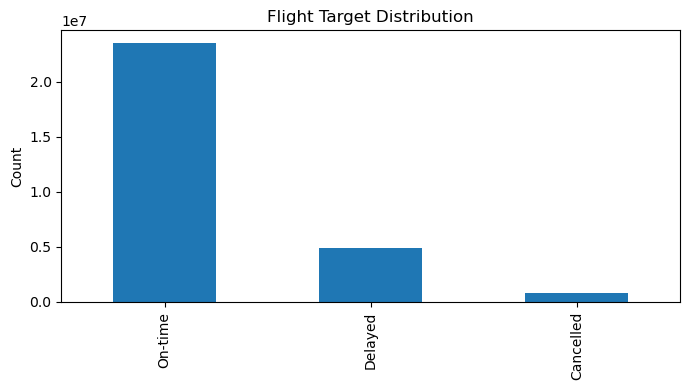

In [11]:
# target distribution
target_counts = f['target_name'].value_counts().reindex(['On-time', 'Delayed', 'Cancelled'])
target_pct = (target_counts / target_counts.sum() * 100).round(2)

print(target_pct)

plt.figure(figsize=(7, 4))
target_counts.index.name = None
ax = target_counts.plot(kind='bar')
ax.set_title('Flight Target Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('')
plt.tight_layout()
plt.show()


## strong class imbalance: 
most flights are on-time and cancelled is rare. 

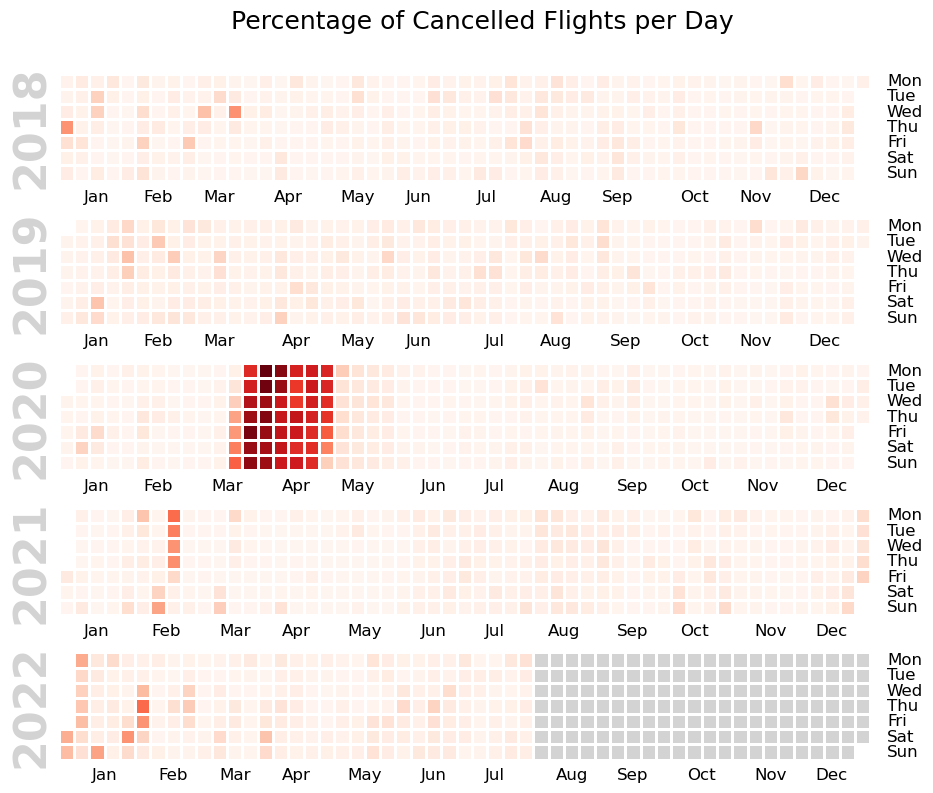

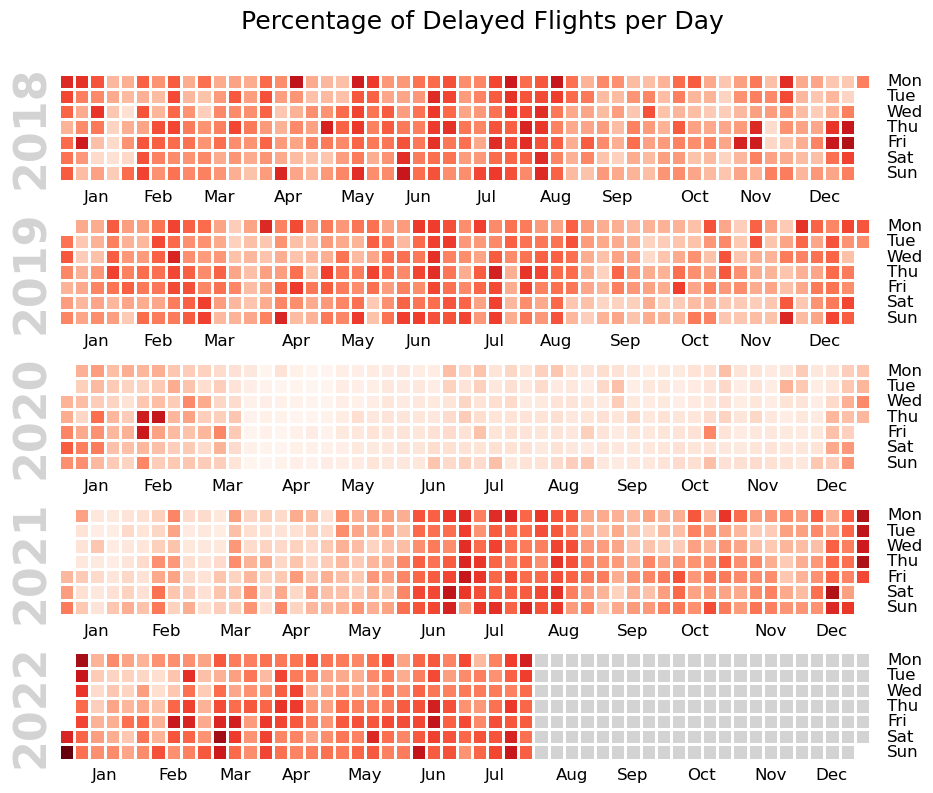

In [12]:
# heatmaps
# daily rates
daily = f.groupby('FlightDate').agg(
    cancel_rate=('target', lambda x: (x == 2).mean()),
    delay_rate=('target', lambda x: (x == 1).mean())
).sort_index()

# cancelled flights per day 
fig, axes = calmap.calendarplot(
    daily['cancel_rate'],
    cmap='Reds',
    fillcolor='lightgrey',
    fig_kws={'figsize': (18, 8)}
)

for ax in axes:
    ax.tick_params(axis='x', labelsize=12, pad=6)
    ax.tick_params(axis='y', labelsize=12, pad=12)
    ax.yaxis.tick_right()

fig.subplots_adjust(left=0.08, right=0.90, top=0.90, hspace=0.35)
fig.suptitle('Percentage of Cancelled Flights per Day', fontsize=18)
plt.show()

# delayed flighter per day
fig, axes = calmap.calendarplot(
    daily['delay_rate'],
    cmap='Reds',
    fillcolor='lightgrey',
    fig_kws={'figsize': (18, 8)}
)

for ax in axes:
    ax.tick_params(axis='x', labelsize=12, pad=6)
    ax.tick_params(axis='y', labelsize=12, pad=12)
    ax.yaxis.tick_right()

fig.subplots_adjust(left=0.08, right=0.90, top=0.90, hspace=0.35)
fig.suptitle('Percentage of Delayed Flights per Day', fontsize=18)
plt.show()


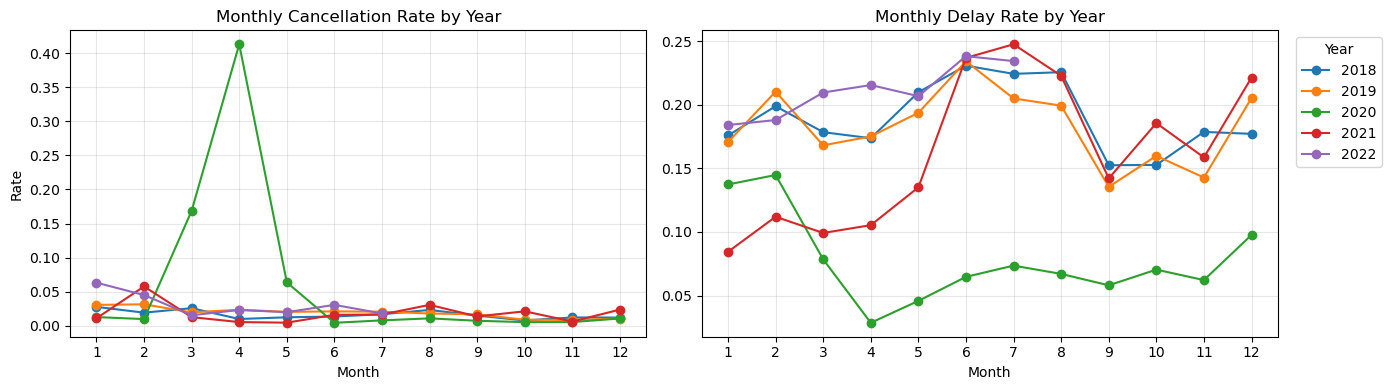

In [13]:
monthly = f.assign(
    year=f['FlightDate'].dt.year,
    month=f['FlightDate'].dt.month
).groupby(['year', 'month']).agg(
    cancel_rate=('target', lambda x: (x == 2).mean()),
    delay_rate=('target', lambda x: (x == 1).mean())
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for y, g in monthly.groupby('year'):
    ax[0].plot(g['month'], g['cancel_rate'], marker='o', label=str(y))
    ax[1].plot(g['month'], g['delay_rate'], marker='o', label=str(y))

ax[0].set_title('Monthly Cancellation Rate by Year')
ax[1].set_title('Monthly Delay Rate by Year')
ax[0].set_ylabel('Rate')

for a in ax:
    a.set_xlabel('Month')
    a.set_xticks(range(1, 13))
    a.grid(alpha=0.3)

ax[1].legend(title='Year', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


* notice the very high monthly cancellation rate, and steep decline in monthly delay rates for 2020 as compared to the other years. (line charts)
* the line charts support the heatmaps which tells us 2020 is an anomoly and will affect our generalization, so removing it is our best option.

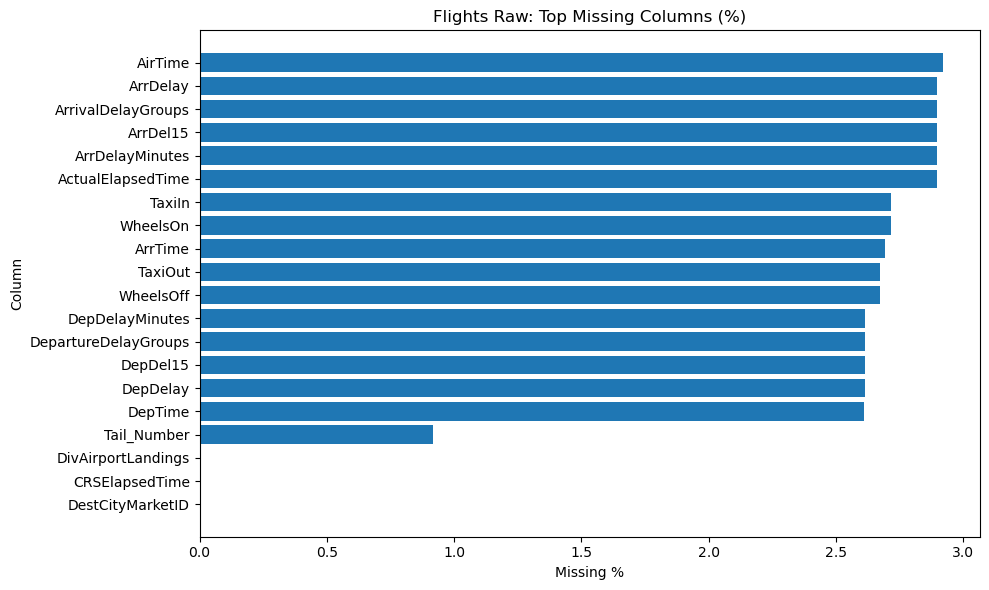

In [14]:
# calc missing percent for cols
flight_missing_pct, n_rows_f = parquet_missingness(
    flights_pf, cols=all_flight_cols, batch_size=300_000)

flight_missing_df = pd.DataFrame({
    'column': flight_missing_pct.index,
    'missing_pct': flight_missing_pct.values
})

plt.figure(figsize=(10, 6))
topn = flight_missing_df.head(20).iloc[::-1]
plt.barh(topn['column'], topn['missing_pct'])
plt.title('Flights Raw: Top Missing Columns (%)')
plt.xlabel('Missing %')
plt.ylabel('Column')
plt.tight_layout()
plt.show()


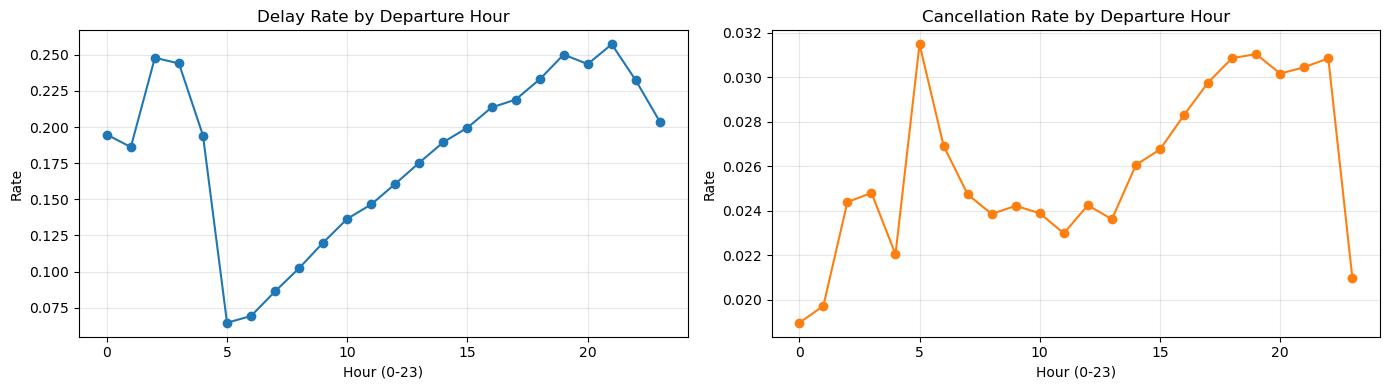

In [15]:
# delay , cancellation rates by hour 
flight_time_df = f.copy()
flight_time_df['dep_hour'] = pd.to_numeric(flight_time_df['CRSDepTime'], errors='coerce').floordiv(100).clip(0, 23)

hourly = flight_time_df.groupby('dep_hour').agg(
    delay_rate=('target', lambda x: (x == 1).mean()),
    cancel_rate=('target', lambda x: (x == 2).mean())
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(hourly['dep_hour'], hourly['delay_rate'], marker='o')
ax[0].set_title('Delay Rate by Departure Hour')
ax[0].set_xlabel('Hour (0-23)')
ax[0].set_ylabel('Rate')
ax[0].grid(alpha=0.3)

ax[1].plot(hourly['dep_hour'], hourly['cancel_rate'], marker='o', color='tab:orange')
ax[1].set_title('Cancellation Rate by Departure Hour')
ax[1].set_xlabel('Hour (0-23)')
ax[1].set_ylabel('Rate')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


* Delay and cancellation risk change strongly by hour
* Delay is lowest around 5am and rises throughout the day, peaking around 7pm
* Cancellation is highest around 5am, declines in the middle of the day and starts increasing at 3pm and hits another peak around 6/7pm.

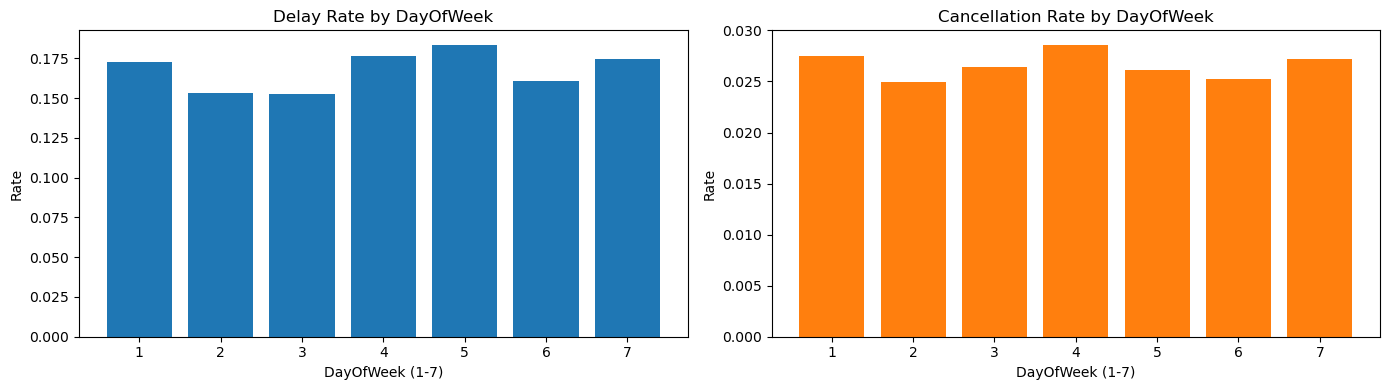

In [16]:
# day of week (delay and cancellation rates)
flight_time_df['dow'] = flight_time_df['FlightDate'].dt.dayofweek + 1

dow = flight_time_df.groupby('dow').agg(
    delay_rate=('target', lambda x: (x == 1).mean()),
    cancel_rate=('target', lambda x: (x == 2).mean())
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].bar(dow['dow'], dow['delay_rate'])
ax[0].set_title('Delay Rate by DayOfWeek')
ax[0].set_xlabel('DayOfWeek (1-7)')
ax[0].set_ylabel('Rate')

ax[1].bar(dow['dow'], dow['cancel_rate'], color='tab:orange')
ax[1].set_title('Cancellation Rate by DayOfWeek')
ax[1].set_xlabel('DayOfWeek (1-7)')
ax[1].set_ylabel('Rate')

plt.tight_layout()
plt.show()



* Delay is highest around day 4-5 and lowest around day 2-3. Day 1 and 7 are also pretty high
* Cancellation is also highest near day 4 followed by day 1 and 7. 

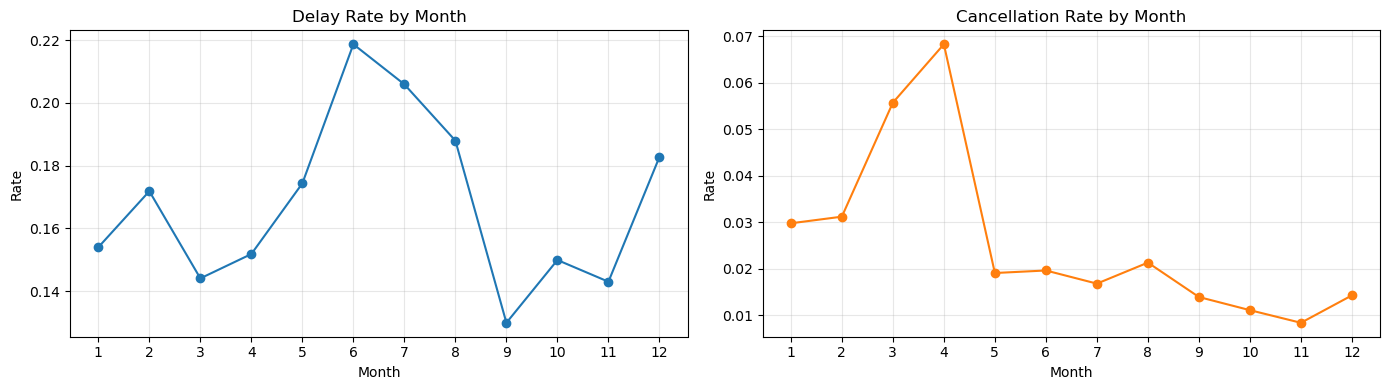

In [17]:
# month 
flight_time_df['month'] = flight_time_df['FlightDate'].dt.month

month = flight_time_df.groupby('month').agg(
    delay_rate=('target', lambda x: (x == 1).mean()),
    cancel_rate=('target', lambda x: (x == 2).mean())
).reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(month['month'], month['delay_rate'], marker='o')
ax[0].set_title('Delay Rate by Month')
ax[0].set_xlabel('Month')
ax[0].set_ylabel('Rate')
ax[0].set_xticks(range(1, 13))
ax[0].grid(alpha=0.3)

ax[1].plot(month['month'], month['cancel_rate'], marker='o', color='tab:orange')
ax[1].set_title('Cancellation Rate by Month')
ax[1].set_xlabel('Month')
ax[1].set_ylabel('Rate')
ax[1].set_xticks(range(1, 13))
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

* Delay peaks in June-August and dips around September
* Cancellation spikes in March-April
* Both support adding seasonal features

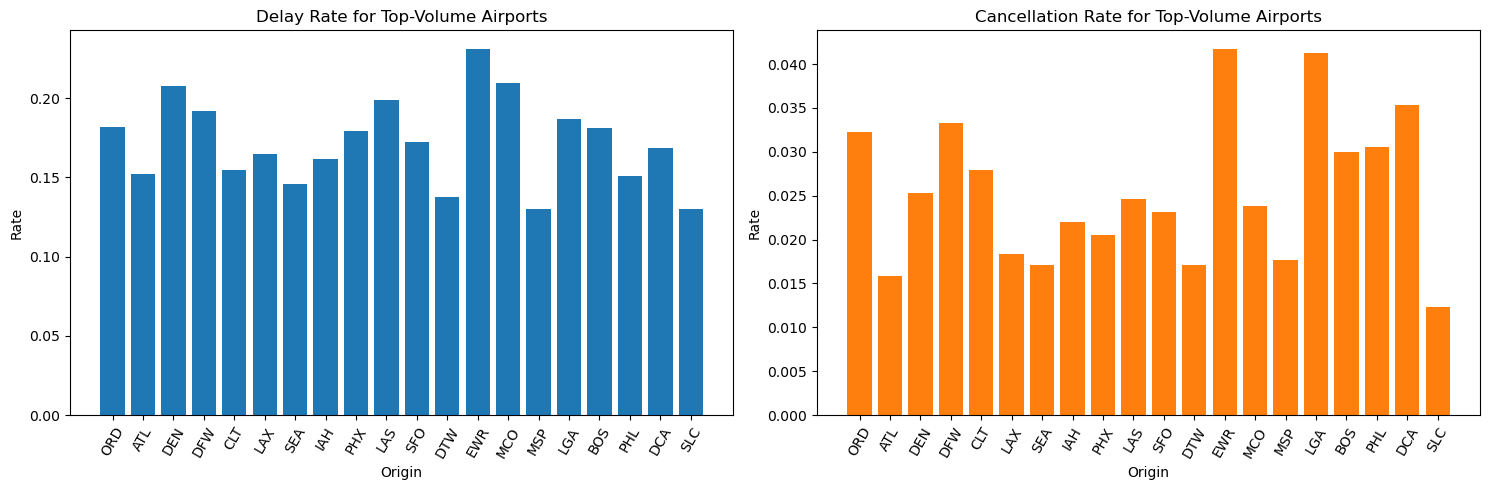

In [18]:
# top airports
airport_stats = f.groupby('Origin').agg(
    flights=('target', 'size'),
    delay_rate=('target', lambda x: (x == 1).mean()),
    cancel_rate=('target', lambda x: (x == 2).mean())
).reset_index()

top_airports = airport_stats.sort_values('flights', ascending=False).head(20)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].bar(top_airports['Origin'], top_airports['delay_rate'])
ax[0].set_title('Delay Rate for Top-Volume Airports')
ax[0].set_xlabel('Origin')
ax[0].set_ylabel('Rate')
ax[0].tick_params(axis='x', rotation=60)

ax[1].bar(top_airports['Origin'], top_airports['cancel_rate'], color='tab:orange')
ax[1].set_title('Cancellation Rate for Top-Volume Airports')
ax[1].set_xlabel('Origin')
ax[1].set_ylabel('Rate')
ax[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()


delay rates change from 0.13 to 0.23, and cancellation ranges from 0.012 to 0.040

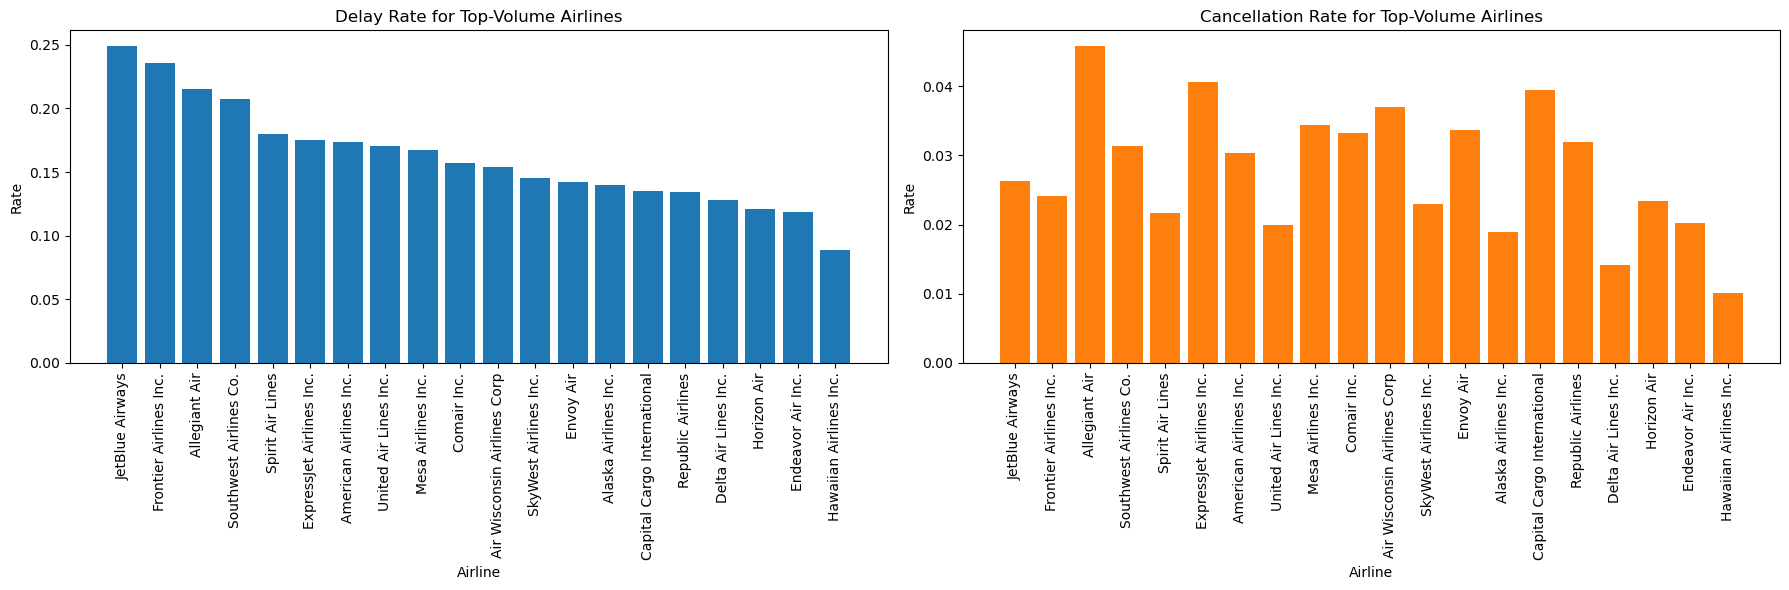

In [19]:
# Airline-level performance

if "Airline" in f.columns:
    airline_stats = f.groupby("Airline").agg(
        flights=("target", "size"),
        delay_rate=("target", lambda x: (x == 1).mean()),
        cancel_rate=("target", lambda x: (x == 2).mean())
    ).reset_index()

    # Focus on top airlines by volume
    top_airlines = airline_stats.sort_values("flights", ascending=False).head(20)

    # Sort by delay rate for clearer patterns
    top_airlines = top_airlines.sort_values("delay_rate", ascending=False)

    fig, ax = plt.subplots(1, 2, figsize=(18, 6))

    # Delay plot
    ax[0].bar(top_airlines["Airline"], top_airlines["delay_rate"])
    ax[0].set_title("Delay Rate for Top-Volume Airlines")
    ax[0].set_xlabel("Airline")
    ax[0].set_ylabel("Rate")
    ax[0].tick_params(axis="x", rotation=90)

    # Cancellation plot
    ax[1].bar(top_airlines["Airline"], top_airlines["cancel_rate"], color='tab:orange')
    ax[1].set_title("Cancellation Rate for Top-Volume Airlines")
    ax[1].set_xlabel("Airline")
    ax[1].set_ylabel("Rate")
    ax[1].tick_params(axis="x", rotation=90)

    plt.tight_layout()
    plt.show()

,dist_bin,n_all,dep_nonnull,arr_nonnull,mean_dep_delay,mean_arr_delay,dep_coverage_pct,arr_coverage_pct
0,"(-0.001, 250.0]",4043985,4043693,4037611,7.729797,3.405162,99.99,99.84
1,"(250.0, 500.0]",7038334,7037967,7025582,8.455165,3.395067,99.99,99.82
2,"(500.0, 750.0]",5556622,5556344,5542909,9.310007,3.928795,99.99,99.75
3,"(750.0, 1000.0]",4375068,4374955,4363143,9.957641,4.147626,100.00,99.73
4,"(1000.0, 1500.0]",4173121,4173058,4159737,10.792244,4.484901,100.00,99.68
5,"(1500.0, 2000.0]",1699389,1699389,1694120,10.432665,2.750555,100.00,99.69
6,"(2000.0, 3000.0]",1478664,1478664,1473361,9.662344,0.980758,100.00,99.64
7,"(3000.0, 6000.0]",51332,51332,51136,11.369945,1.593965,100.00,99.62


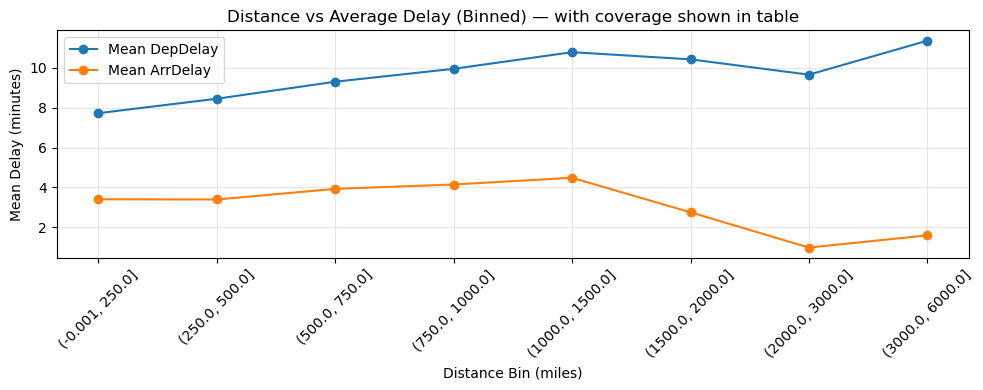

In [20]:
# Distance vs Delay (binned) + coverage (fixes warning + avoids misleading long-flight drop)

cols_needed = ["Distance", "DepDelay", "ArrDelay", "target_name"]
tmp = f[cols_needed].copy()

# Keep only non-cancelled for delay-minutes plots
tmp = tmp[tmp["target_name"] != "Cancelled"].copy()

# Numeric cleanup
tmp["Distance"] = pd.to_numeric(tmp["Distance"], errors="coerce")
tmp["DepDelay"] = pd.to_numeric(tmp["DepDelay"], errors="coerce")
tmp["ArrDelay"] = pd.to_numeric(tmp["ArrDelay"], errors="coerce")
tmp = tmp.dropna(subset=["Distance"])

# Distance bins (miles)
bins = [0, 250, 500, 750, 1000, 1500, 2000, 3000, 6000]
tmp["dist_bin"] = pd.cut(tmp["Distance"], bins=bins, include_lowest=True)

agg = tmp.groupby("dist_bin", observed=True).agg(
    n_all=("Distance", "size"),
    dep_nonnull=("DepDelay", lambda s: s.notna().sum()),
    arr_nonnull=("ArrDelay", lambda s: s.notna().sum()),
    mean_dep_delay=("DepDelay", "mean"),
    mean_arr_delay=("ArrDelay", "mean"),
).reset_index()

# Coverage percentages (how much of the bin actually has delay values)
agg["dep_coverage_pct"] = (agg["dep_nonnull"] / agg["n_all"] * 100).round(2)
agg["arr_coverage_pct"] = (agg["arr_nonnull"] / agg["n_all"] * 100).round(2)

display(agg)

# Plot means
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(agg["dist_bin"].astype(str), agg["mean_dep_delay"], marker="o", label="Mean DepDelay")
ax.plot(agg["dist_bin"].astype(str), agg["mean_arr_delay"], marker="o", label="Mean ArrDelay")
ax.set_title("Distance vs Average Delay (Binned) — with coverage shown in table")
ax.set_xlabel("Distance Bin (miles)")
ax.set_ylabel("Mean Delay (minutes)")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Distance is positively associated with departure delays. Average departure delay steadily increases from short-haul to long-haul flights, suggesting longer routes are more exposed to scheduling and operational disruptions. In contrast, arrival delay increases up to medium-haul distances (around 1000–1500 miles) but then declines for longer flights. Since delay coverage remains above 99% across all bins, this pattern is not driven by missing data. This may reflect schedule padding or operational buffers in long-haul routes. These findings support including distance-based and nonlinear interaction features in modeling.

In [21]:
# Light numeric correlation with target (proxy)

num_cols = []
for c in ["Distance", "Month", "DayofMonth", "DayOfWeek", "CRSDepTime", "DepDelay", "ArrDelay"]:
    if c in f.columns:
        num_cols.append(c)

tmp = f[num_cols + ["target"]].copy()
for c in num_cols:
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

corr = tmp.corr(numeric_only=True)["target"].drop("target").sort_values(key=lambda s: s.abs(), ascending=False)
print("Correlation with target (magnitude-sorted):")
print(corr)

Correlation with target (magnitude-sorted):
DepDelay      0.572497
ArrDelay      0.556220
CRSDepTime    0.127570
Month        -0.046930
DayOfWeek     0.007879
Distance      0.005505
DayofMonth    0.004856
Name: target, dtype: float64


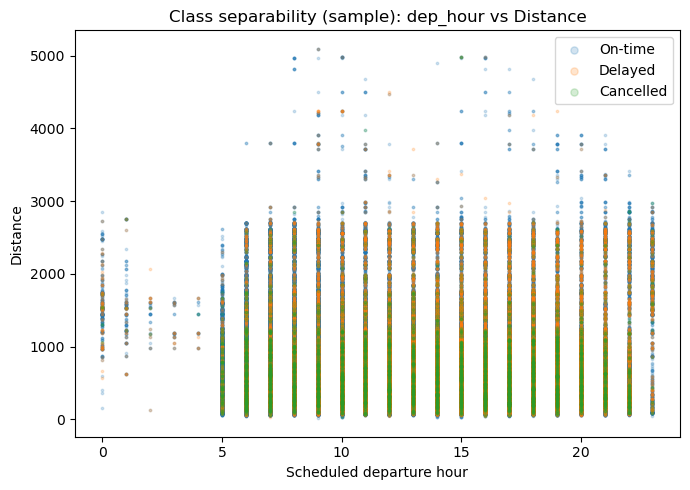

In [22]:
# Class separability: Distance vs CRS departure hour (scatter sample)
df_s = f.sample(n=min(200_000, len(f)), random_state=42).copy()  # sampling for speed
df_s["Distance"] = pd.to_numeric(df_s.get("Distance"), errors="coerce")

# convert CRSDepTime HHMM -> hour (0-23)
if "CRSDepTime" in df_s.columns:
    df_s["dep_hour"] = pd.to_numeric(df_s["CRSDepTime"], errors="coerce").floordiv(100).clip(0, 23)

plt.figure(figsize=(7,5))
for cls, mk in [("On-time","."), ("Delayed","."), ("Cancelled",".")]:
    sub = df_s[df_s["target_name"] == cls]
    plt.scatter(sub["dep_hour"], sub["Distance"], s=3, alpha=0.2, label=cls)
plt.title("Class separability (sample): dep_hour vs Distance")
plt.xlabel("Scheduled departure hour")
plt.ylabel("Distance")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

# Weather

In [9]:
weather_cols = ['valid', 'airport_code', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']
weather_cols_use = [c for c in weather_cols if c in weather_pf.schema.names]

weather_df = pd.read_parquet(weather_path, columns=weather_cols_use)
weather_df['valid'] = pd.to_datetime(weather_df['valid'], errors='coerce')
weather_df['hour'] = weather_df['valid'].dt.hour

for c in ['tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']:
    if c in weather_df.columns:
        weather_df[c] = pd.to_numeric(weather_df[c], errors='coerce')

print('Weather shape:', weather_df.shape)
display(weather_df.head())
display(weather_df.dtypes)


Weather shape: (15620936, 9)


,valid,airport_code,tmpf,vsby,sknt,p01i,relh,gust,hour
0,2018-01-01 00:00:00,ATL,NaN,10.0,14.0,NaN,NaN,NaN,0
1,2018-01-01 00:05:00,ATL,NaN,10.0,13.0,NaN,NaN,NaN,0
2,2018-01-01 00:10:00,ATL,NaN,10.0,12.0,NaN,NaN,18.0,0
3,2018-01-01 00:15:00,ATL,NaN,10.0,11.0,NaN,NaN,NaN,0
4,2018-01-01 00:20:00,ATL,NaN,10.0,12.0,NaN,NaN,NaN,0


valid           datetime64[ns]
airport_code            object
tmpf                   float64
vsby                   float64
sknt                   float64
p01i                   float64
relh                   float64
gust                   float64
hour                     int32
dtype: object

,column,missing_pct
0,gust,94.773437
1,relh,90.700276
2,tmpf,90.688471
3,p01i,87.226873
4,sknt,1.057542
5,vsby,0.141003
6,valid,0.000000
7,airport_code,0.000000
8,hour,0.000000


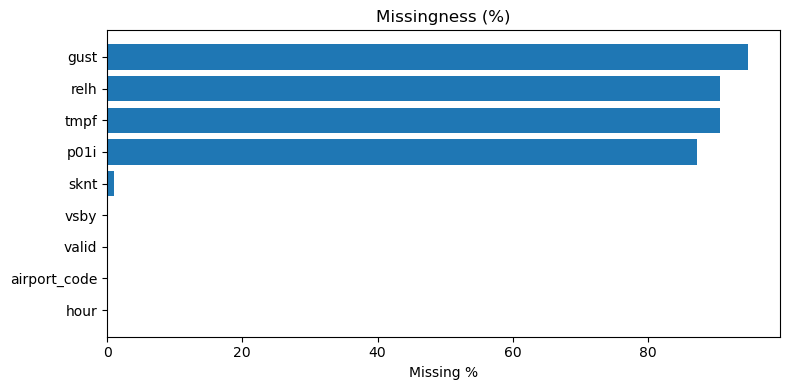

In [10]:
# missingness
weather_missing = (weather_df.isna().mean() * 100).sort_values(ascending=False)
weather_missing_df = weather_missing.reset_index()
weather_missing_df.columns = ['column', 'missing_pct']

display(weather_missing_df)

plt.figure(figsize=(8, 4))
topw = weather_missing_df.head(10).iloc[::-1]
plt.barh(topw['column'], topw['missing_pct'])
plt.title('Missingness (%)')
plt.xlabel('Missing %')
plt.tight_layout()
plt.show()


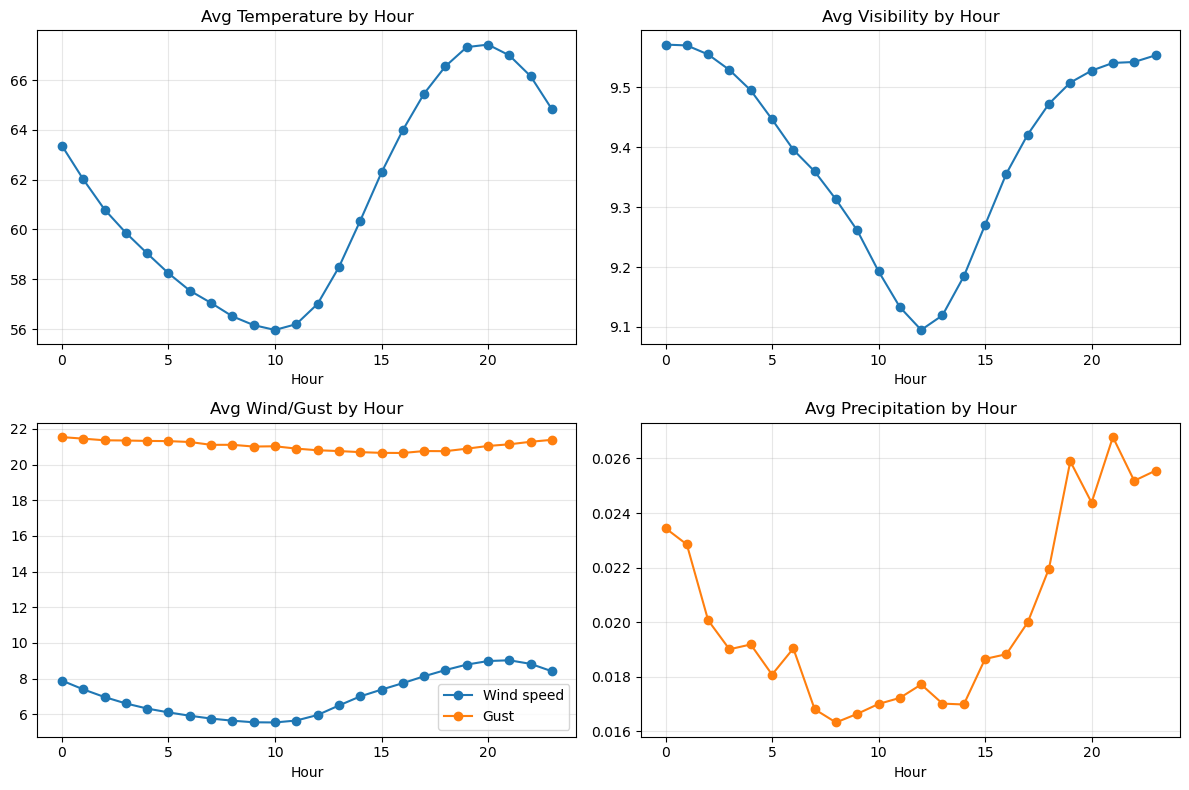

In [25]:
# houlry weather avaerages 
hourly_weather = weather_df.groupby('hour').agg({
    'tmpf':'mean',
    'vsby':'mean',
    'sknt':'mean',
    'p01i':'mean',
    'gust':'mean'
}).reset_index()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].plot(hourly_weather['hour'], hourly_weather['tmpf'], marker='o')
ax[0,0].set_title('Avg Temperature by Hour')

ax[0,1].plot(hourly_weather['hour'], hourly_weather['vsby'], marker='o')
ax[0,1].set_title('Avg Visibility by Hour')

ax[1,0].plot(hourly_weather['hour'], hourly_weather['sknt'], marker='o', label='Wind speed')
ax[1,0].plot(hourly_weather['hour'], hourly_weather['gust'], marker='o', label='Gust')
ax[1,0].set_title('Avg Wind/Gust by Hour')
ax[1,0].legend()

ax[1,1].plot(hourly_weather['hour'], hourly_weather['p01i'], marker='o', color='tab:orange')
ax[1,1].set_title('Avg Precipitation by Hour')

for a in ax.ravel():
    a.set_xlabel('Hour')
    a.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Merged F+W 

In [11]:
# merged columns + dtypes
m = pd.read_parquet(merged_path)

print('Merged shape:', m.shape)

merged_schema = pd.DataFrame({
    'column': m.columns,
    'dtype': m.dtypes.astype(str).values
})

display(merged_schema)

Merged shape: (24165691, 20)


,column,dtype
0,FlightDate,datetime64[us]
1,Airline,string
2,Origin,string
3,OriginState,string
4,CRSDepTime,int64
5,Cancelled,bool
6,DepDelay,float64
7,Distance,float64
8,Month,int64
9,DayOfWeek,int64


In [12]:
# target creation:
m['is_cancelled'] = m['Cancelled'].astype(np.int8)
m['is_delayed'] = ((~m['Cancelled']) & (m['DepDelay'] >= 15)).astype(np.int8)
m['is_on_time'] = ((m['is_cancelled'] == 0) & (m['is_delayed'] == 0)).astype(np.int8)


m['target'] = np.select(
    [m['is_cancelled'] == 1, m['is_delayed'] == 1],
    [2, 1],
    default=0
).astype(np.int8)

m['target_name'] = m['target'].map({0: 'On-time', 1: 'Delayed', 2: 'Cancelled'})

Target distribution (%)
target_name
On-time      79.53
Delayed      18.50
Cancelled     1.97
Name: count, dtype: float64


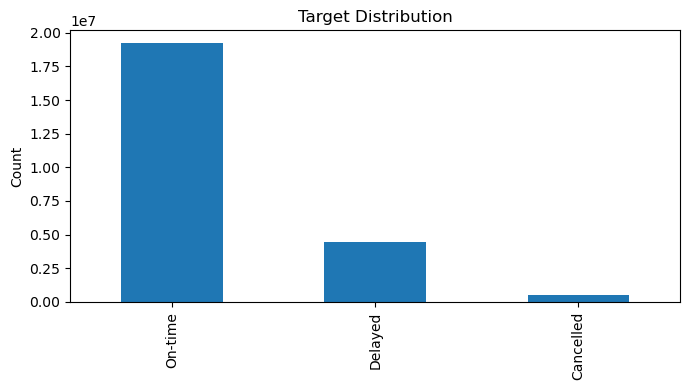

In [13]:
# target distribution 
target_counts = m['target_name'].value_counts().reindex(['On-time', 'Delayed', 'Cancelled'])
target_pct = (target_counts / target_counts.sum() * 100).round(2)

print('Target distribution (%)')
print(target_pct)

ax = target_counts.plot(kind='bar', figsize=(7, 4))
ax.set_title('Target Distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()



* highly imbalanced classes

Missing data (%)
gust        34.238
relh         3.354
p01i         3.261
tmpf         3.261
sknt         3.260
vsby         3.260
DepDelay     1.917
dtype: float64


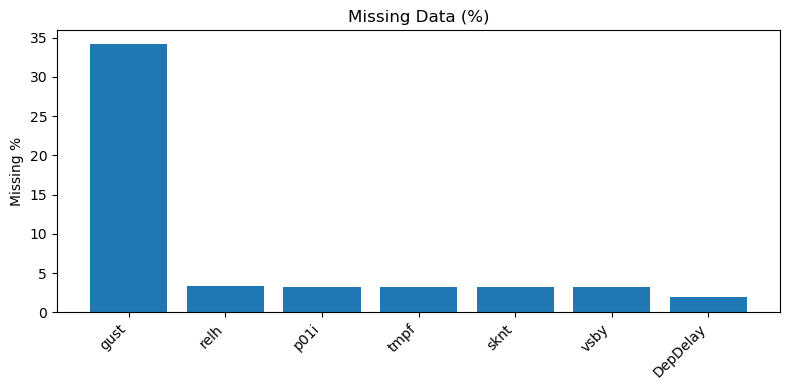

In [14]:
# finding the features with missing values 
missing_pct = (m.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print('Missing data (%)')
print(missing_pct.round(3))

plt.figure(figsize=(8, 4))
plt.bar(missing_pct.index, missing_pct.values)
plt.title('Missing Data (%)')
plt.xlabel('')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* Missing data is concentrated in the weather fields, especially gust

Weather source share (%):
weather_source
airport_hour_match    60.16
region_hour_match     36.57
still_missing          3.26
Name: proportion, dtype: Float64


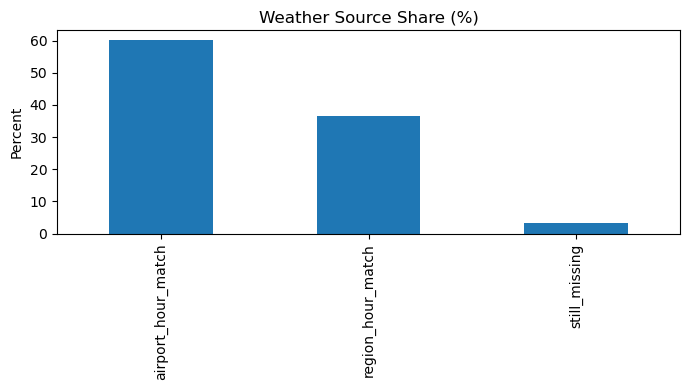

In [30]:
# checking how weather values were distributed for airports with missing data
ws_pct = (m['weather_source'].value_counts(normalize=True) * 100).round(2)
print('Weather source share (%):')
print(ws_pct)

plt.figure(figsize=(7, 4))
ws_pct.sort_values(ascending=False).plot(kind='bar')
plt.title('Weather Source Share (%)')
plt.xlabel('')
plt.ylabel('Percent')
plt.tight_layout()
plt.show()


* Most rows have airport-hour weather, many use region-hour fallback which was created using the U.S. Census map, while only a small share remains unmatched

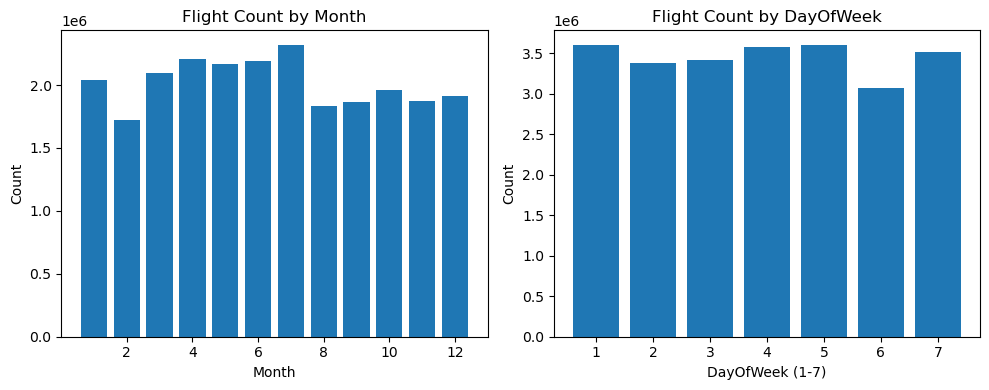

In [31]:
# flight count for month and day of week 
month_n = m.groupby('Month').size()
dow_n = m.groupby('DayOfWeek').size()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(month_n.index, month_n.values)
axes[0].set_title('Flight Count by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')

axes[1].bar(dow_n.index, dow_n.values)
axes[1].set_title('Flight Count by DayOfWeek')
axes[1].set_xlabel('DayOfWeek (1-7)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


* There are more flights within June and July (Summer months)
* During the week, there are more flights Monday, Thursday, Friday, Sunday

In [ ]:
# distribution of weather features by targets 
weather_cols = ['tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust']
weather_cols = [c for c in weather_cols if c in m.columns]

fig, axes = plt.subplots(len(plot_cols), 1, figsize=(8, 3 * len(plot_cols)))
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    m.boxplot(column=col, by='target_name', ax=ax)
    ax.set_title(f'{col} by Target Class')
    ax.set_xlabel('Target')
    ax.set_ylabel(col)

plt.suptitle('')  
plt.tight_layout()
plt.show()


* Delayed/Cancelled flights ten to have lower visibility and more extremem weather values than on-time flights

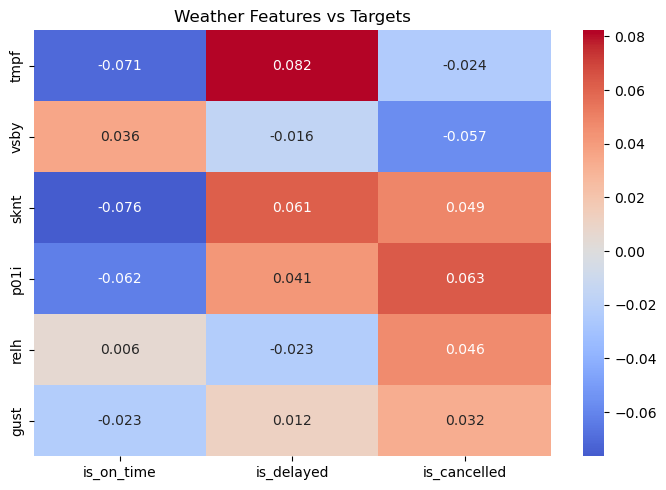

In [33]:
# weather features vs targets (sampled)
sample_cols = weather_cols + ['is_on_time', 'is_delayed', 'is_cancelled']
corr_sample = m[sample_cols].copy()

for c in sample_cols:
    corr_sample[c] = pd.to_numeric(corr_sample[c], errors='coerce')

corr_sample = corr_sample.dropna(subset=weather_cols)
# sampling for quicker output 
corr_sample = corr_sample.sample(n=min(1_000_000, len(corr_sample)), random_state=42)

target_corr = corr_sample.corr(method='spearman').loc[
    weather_cols, ['is_on_time', 'is_delayed', 'is_cancelled']
]

plt.figure(figsize=(7, 5))
sns.heatmap(target_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Weather Features vs Targets')
plt.tight_layout()
plt.show()

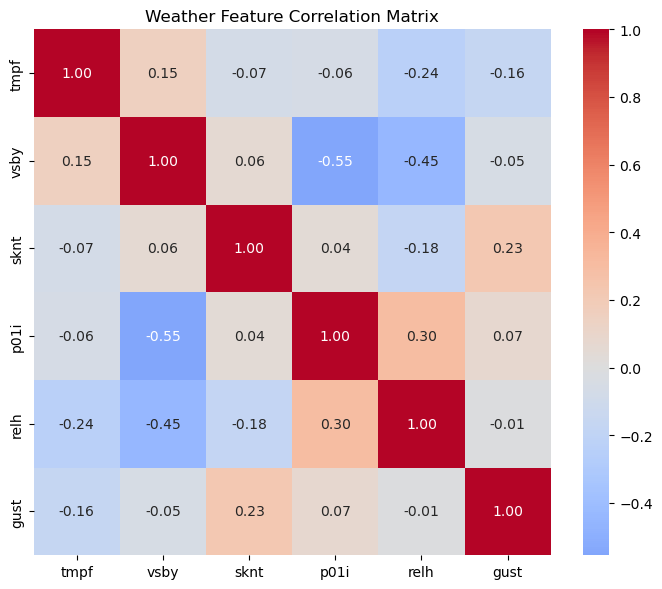

In [34]:
# weather feature correlation 
weather_corr = corr_sample[weather_cols].corr(method='spearman')

plt.figure(figsize=(7, 6))
sns.heatmap(weather_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Weather Feature Correlation Matrix')
plt.tight_layout()
plt.show()


In [35]:
# getting stats on the precipitation levels ---> highest correlation for cancelled
m.loc[m['p01i'].notna() & (m['p01i'] > 0), 'p01i'].describe()

count    3.393135e+06
mean     2.204843e-01
std      6.596833e-01
min      8.333333e-04
25%      1.916667e-02
50%      6.000000e-02
75%      1.811111e-01
max      3.398000e+01
Name: p01i, dtype: float64

target_name,Cancelled,Delayed,On-time
p01i,,,
0-0.01,2.32,18.80,78.88
0.01-0.1,3.00,19.95,77.05
0.1-0.5,4.93,24.42,70.65
0.5-1.0,6.44,27.93,65.63
>1.0,7.34,34.23,58.43


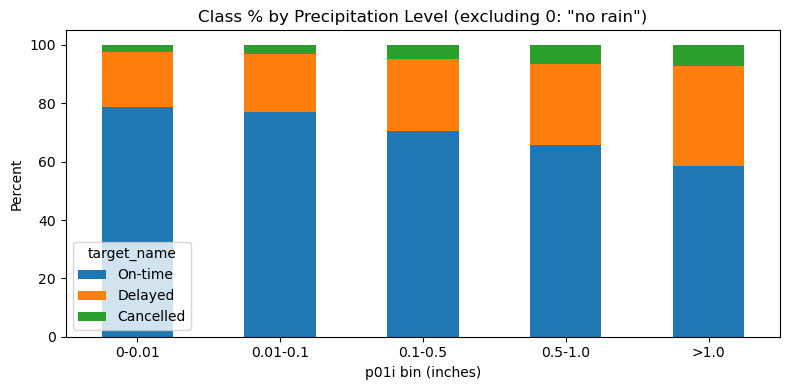

In [36]:
mask_rain = m['p01i'].notna() & (m['p01i'] > 0)

# bins made with stats help (only including 0 to capture min precip levels)
bins_rain = [0, 0.01, 0.1, 0.5, 1.0, np.inf]
labels_rain = ['0-0.01', '0.01-0.1', '0.1-0.5', '0.5-1.0', '>1.0']

p01i_bin_rain = pd.cut(
    m.loc[mask_rain, 'p01i'],
    bins=bins_rain,
    labels=labels_rain,
    include_lowest=True
)

p01i_class_rain = pd.crosstab(
    p01i_bin_rain,
    m.loc[mask_rain, 'target_name'],
    normalize='index'
) * 100

display(p01i_class_rain.round(2))

ax = p01i_class_rain[['On-time', 'Delayed', 'Cancelled']].plot(
    kind='bar', stacked=True, figsize=(8, 4)
)
ax.set_title('Class % by Precipitation Level (excluding 0: "no rain")')
ax.set_xlabel('p01i bin (inches)')
ax.set_ylabel('Percent')
ax.legend(title='target_name')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


* As precipitation intensity increases, delayed/cancelled flights also rise as on-time declines. 

In [37]:
# Extreme weather indicators (nonlinear airline decision thresholds)

m["low_visibility"] = (m["vsby"] < 3).astype(int)
m["very_low_visibility"] = (m["vsby"] < 1).astype(int)

m["high_wind"] = (m["sknt"] > 20).astype(int)
m["extreme_wind"] = (m["sknt"] > 30).astype(int)

m["heavy_rain"] = (m["p01i"] > 0.5).astype(int)
m["very_heavy_rain"] = (m["p01i"] > 1.0).astype(int)

print("Extreme weather feature prevalence (%):")
display(m[
    ["low_visibility","very_low_visibility","high_wind",
     "extreme_wind","heavy_rain","very_heavy_rain"]
].mean() * 100)

Extreme weather feature prevalence (%):


low_visibility         1.726311
very_low_visibility    0.441663
high_wind              0.636361
extreme_wind           0.008814
heavy_rain             1.334007
very_heavy_rain        0.576942
dtype: float64

In [38]:
# Impact of extreme weather on delay and cancellation

for col in ["low_visibility", "high_wind", "heavy_rain"]:
    print(f"\nTarget distribution when {col} = 1:")
    display(
        (m[m[col] == 1]["target_name"].value_counts(normalize=True) * 100).round(2)
    )


Target distribution when low_visibility = 1:


target_name
On-time      65.42
Delayed      26.75
Cancelled     7.83
Name: proportion, dtype: float64


Target distribution when high_wind = 1:


target_name
On-time      64.12
Delayed      28.18
Cancelled     7.70
Name: proportion, dtype: float64


Target distribution when heavy_rain = 1:


target_name
On-time      62.52
Delayed      30.65
Cancelled     6.83
Name: proportion, dtype: float64

Extreme weather conditions significantly shift the class distribution, with delays and cancellations increasing sharply under low visibility, strong winds, and heavy precipitation. This supports our hypothesis that airline operational decisions follow nonlinear threshold behavior. These engineered indicators are expected to improve cancellation and delay detection in tree-based models.

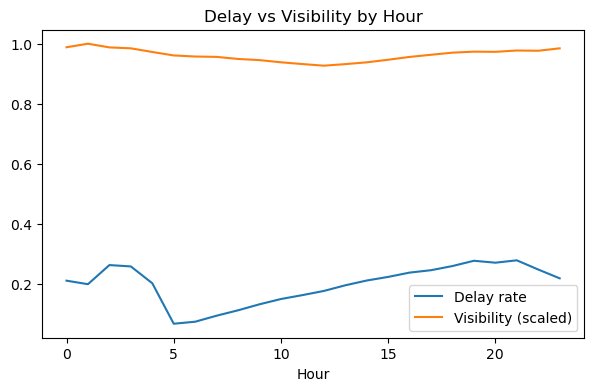

In [39]:
# Interaction: weather vs time-of-day

delay_by_hour = m.groupby("dep_hour")["is_delayed"].mean()
vis_by_hour = m.groupby("dep_hour")["vsby"].mean()

plt.figure(figsize=(7,4))
plt.plot(delay_by_hour.index, delay_by_hour.values, label="Delay rate")
plt.plot(vis_by_hour.index, vis_by_hour.values / vis_by_hour.max(), label="Visibility (scaled)")
plt.legend()
plt.title("Delay vs Visibility by Hour")
plt.xlabel("Hour")
plt.show()

The results show a clear increase in delay rates over the course of the day despite relatively stable visibility levels. This suggests that airline delays are driven by nonlinear interactions between weather and operational pressure, supporting the use of interaction features and nonlinear models such as XGBoost.

In [16]:
# Bias check: flights with vs without matched weather 

merged_df = pd.read_parquet("flight_weather_merged.parquet")

# pick a METAR column that should exist when weather is present
anchor = "vsby"  # visibility (common METAR field). 

if anchor not in merged_df.columns:
    # auto-pick a backup from common metar fields
    for cand in ["tmpf", "sknt", "alti", "drct", "relh", "dwpf"]:
        if cand in merged_df.columns:
            anchor = cand
            break

print("Using anchor weather column:", anchor)

missing_weather = merged_df[anchor].isna()
print("Merged rows:", len(merged_df))
print("Missing-weather rows:", missing_weather.sum())
print("Missing-weather %:", round(missing_weather.mean()*100, 2), "%")

# Compare outcome distribution (uses your label fields if present)
target_col = "target_name" if "target_name" in merged_df.columns else ("target" if "target" in merged_df.columns else None)

if target_col is not None:
    print("\nTarget distribution WITH weather:")
    print((merged_df.loc[~missing_weather, target_col].value_counts(normalize=True)*100).round(2))

    print("\nTarget distribution MISSING weather:")
    print((merged_df.loc[missing_weather, target_col].value_counts(normalize=True)*100).round(2))

# Compare top origins (bias toward certain airports)
if "Origin" in merged_df.columns:
    print("\nTop origins WITH weather:")
    print(merged_df.loc[~missing_weather, "Origin"].value_counts(normalize=True).head(10).round(4))

    print("\nTop origins MISSING weather:")
    print(merged_df.loc[missing_weather, "Origin"].value_counts(normalize=True).head(10).round(4))

Using anchor weather column: vsby
Merged rows: 24165691
Missing-weather rows: 787734
Missing-weather %: 3.26 %

Top origins WITH weather:
Origin
ORD    0.0475
ATL    0.0462
DEN    0.0399
DFW    0.0364
CLT    0.0299
LAX    0.0297
SEA    0.0245
IAH    0.0242
PHX    0.0229
LAS    0.0228
Name: proportion, dtype: Float64

Top origins MISSING weather:
Origin
ORD    0.0474
ATL    0.0457
DEN      0.04
DFW    0.0362
LAX    0.0298
CLT    0.0298
SEA    0.0246
IAH     0.024
LAS     0.023
PHX     0.023
Name: proportion, dtype: Float64


After integrating hierarchical airport and regional weather data, only a small fraction of flights remain unmatched. A comparison of airport distributions between flights with and without weather data shows nearly identical patterns, suggesting that missingness is approximately random. Therefore, retaining these flights does not introduce systematic bias. This supports the decision to keep all observations and allow the model to handle missing weather values, rather than dropping a significant portion of the dataset.